# Handwritten Digit Recognition

## Libraries used

In [2]:
# %pip install tensorflow
# %pip install keras
# %pip install scikit-image
# %pip install numpy

# uncomment the above lines to the top of your code to install the necessary packages, and add any other packages you may need in the same format.
import numpy as np
import tensorflow
import keras
import os
import glob
import skimage
from skimage import io
import random
import matplotlib.pyplot as plt
import pandas as pd
from skimage.transform import resize
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
%matplotlib inline

## Importing Unprocessed data, cleaning and preprocessing

### Importing data

In [3]:
dataset = pd.read_csv("/content/data/optdigits-orig.cv",
                 delim_whitespace=True, header=None, skiprows=21) # path to unprocessed dataset

<ipython-input-3-6a996cc90c49>:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset = pd.read_csv("/content/data/optdigits-orig.cv",


### Plotting Image from data

In [4]:
string = dataset.iloc[0, 0] # get the first row of the first digit
print(string) # print row of the first digit
print(len(string)) # this should give us the number of pixels in each row of a digit, thus the shape of the image

00000000000001100111100000000000
32


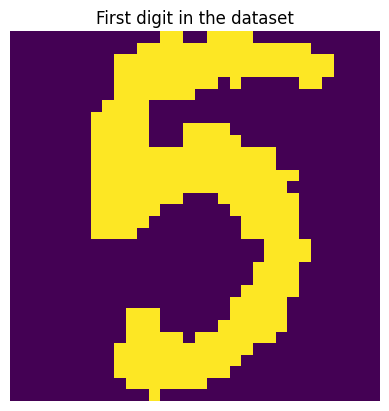

Unique values in image: [0 1]


In [5]:
lines = [list(map(int, dataset.iloc[i, 0].strip())) for i in range(32)] # get the first 32 rows of the first digit and convert them to a list of lists
image = np.array(lines) # convert the list of lists to a numpy array


plt.imshow(image) # plot
plt.title("First digit in the dataset")
plt.axis('off')
plt.show()
print("Unique values in image:", np.unique(image))


> Since our data is just binary and not images, we will need to preprocess the data in a way that simulates real world image data. That way it will make the models train on data that can be applied to images. We do that by taking our binary data and converting into a bitmap so the CV understands the difference in pixel coloring.

Digit and Label in binary image format: 



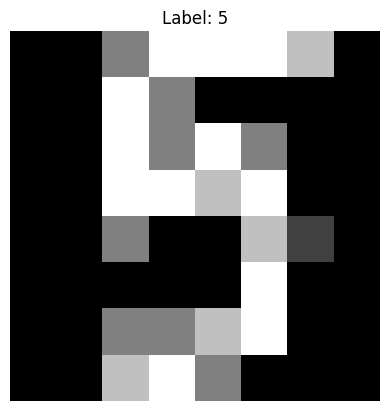

Digit and Label in bitmap format: 

[[ 0  0  8 16 16 16 12  0]
 [ 0  0 16  8  0  0  0  0]
 [ 0  0 16  8 16  8  0  0]
 [ 0  0 16 16 12 16  0  0]
 [ 0  0  8  0  0 12  4  0]
 [ 0  0  0  0  0 16  0  0]
 [ 0  0  8  8 12 16  0  0]
 [ 0  0 12 16  8  0  0  0]]
Label:  5


In [6]:
lines = [list(map(int, dataset.iloc[i, 0].strip())) for i in range(len(dataset) - 1)]  # see each row as digits, no whitespace
digits = [] # array to hold digits
labels = [] # array to hold labels
lines_per_digit = 33 # number of lines per digit
total_lines = len(lines)
num_of_digits =  total_lines // lines_per_digit  # number of digits divded by lines per digit and label ensuring we only process if we have enough lines

for i in range (num_of_digits):
    digit_start = i * 33
    digit_lines = lines[digit_start:digit_start + 32] # get the lines for the digit
    label_line = dataset.iloc[digit_start + 32, 0].strip() # get the label line from the dataset, .strip() to remove any nonchar

    binary_digit = np.array([[int(num) for num in list(row)] for row in digit_lines]) # convert binary digit to 2D array
    resize_digit = resize(binary_digit, (8, 8),  anti_aliasing=False, preserve_range=True ) # resize to 8x8
    bitmap_digit = np.round(resize_digit *16 ).astype(int) # convert to bitmap 0-16

    digits.append(bitmap_digit) # append to digits array
    labels.append(int(label_line)) # append to labels array

print("Digit and Label in binary image format: \n")
plt.imshow(digits[0], cmap='gray', vmin=0, vmax=16) # show the first digit
plt.title(f"Label: {labels[0]}") # show the label
plt.axis('off') # hide the axis
plt.show() # show the image

print("Digit and Label in bitmap format: \n")
print(digits[0])
print("Label: ", labels[0]) # show the label

> lets see more examples to make sure our data is processed right

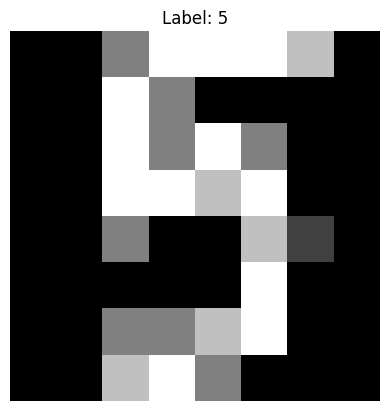

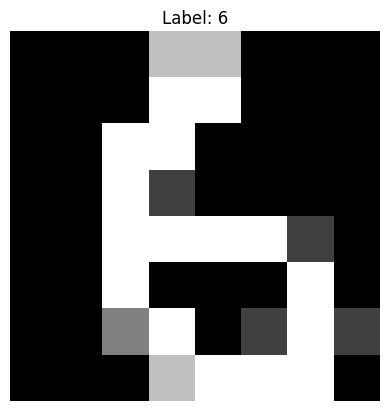

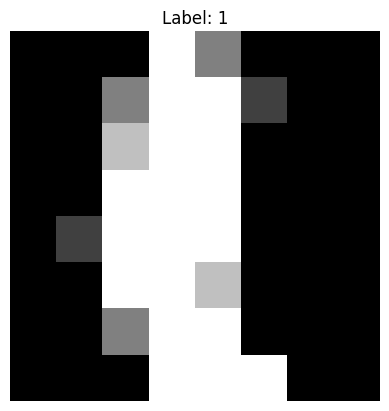


label: 5
 0  0  8 16 16 16 12  0
 0  0 16  8  0  0  0  0
 0  0 16  8 16  8  0  0
 0  0 16 16 12 16  0  0
 0  0  8  0  0 12  4  0
 0  0  0  0  0 16  0  0
 0  0  8  8 12 16  0  0
 0  0 12 16  8  0  0  0

label: 6
 0  0  0 12 12  0  0  0
 0  0  0 16 16  0  0  0
 0  0 16 16  0  0  0  0
 0  0 16  4  0  0  0  0
 0  0 16 16 16 16  4  0
 0  0 16  0  0  0 16  0
 0  0  8 16  0  4 16  4
 0  0  0 12 16 16 16  0

label: 1
 0  0  0 16  8  0  0  0
 0  0  8 16 16  4  0  0
 0  0 12 16 16  0  0  0
 0  0 16 16 16  0  0  0
 0  4 16 16 16  0  0  0
 0  0 16 16 12  0  0  0
 0  0  8 16 16  0  0  0
 0  0  0 16 16 16  0  0


In [7]:
for i in range(3):
    plt.imshow(digits[i], cmap='gray', vmin=0, vmax=16)
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')
    plt.show()


for i in range(3):
    print(f"\nlabel: {labels[i]}")
    for row in digits[i]:
        print(" ".join(f"{val:2}" for val in row))

## Data preperation for models

### Prepare data for SVM

In [12]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
x = np.array([img.flatten() for img in digits]) # flatten the images to 1D array for SVM, since it cannot see spatial
y = np.array(labels) # labels for the images
print(x.shape)
print(y.shape)

xtrain_svm, xtest_svm, ytrain_svm, ytest_svm = train_test_split(x, y, test_size=0.2, random_state=42) # split the data into training and testing sets

(945, 64)
(945,)


### Prepare data for CNN

In [9]:
x = np.array(digits) # convert to numpy array
y= np.array(labels) # convert to numpy array

x = x/16.0 # normalizs the value from 0-16 since CNN preform better when using smaller input, hence range of 0.0-1.0
x = x.reshape(-1,8,8,1) # reshape to 4D array for CNNs, array would be like this [samples, height, widthh, channels]
y = to_categorical(y, num_classes=10) # convert to categorical aka one-hot encoding, like 6 would be [0,0,0,0,0,0,1,0,0,0]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42) # split the data into training and testing sets

## Building the models

### Building SVM Model

In [31]:
from sklearn import svm
# Feature scaling, normalize using Min-Max scaling
scaler = MinMaxScaler()

# Fit the scaler on the training data
scaler.fit(xtrain_svm)
x_train_scale = scaler.transform(xtrain_svm)
x_test_scale = scaler.transform(xtest_svm)
print(x_train_scale.mean())
print(x_test_scale.std())
model_svm = svm.SVC()

0.30972360008818345
0.42554095484220344


### Building CNN model

In [19]:
cnn_model = Sequential() # create a sequential model from tensorflow keras library, this creates a stack of layers


# creating convulutional layers
 # first layer with RelU function and 32 nuerons with 3x3 kernel (or grid) size, adding padding to since without it shape shrinks too fast
cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1), padding='same'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2))) # MaxPool to shrink image size to 2x2 and keep the maxiumum value in that grid, helpful for reducing image size
cnn_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same')) # second layer with RelU function and 64 nuerons, just to make sure it learns more features
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

cnn_model.add(Flatten()) # flatten feature map to 1D array before passing it to the dense layer

cnn_model.add(Dense(128, activation='relu')) # dense layer with 128 neurons so the model can combine everything it learned from the convulutional layers
cnn_model.add(Dense(10, activation='softmax')) # output layer with 10 nuerons for the digits from 0-9 and using softmax to get the probability of each digit

# compile the model with adam optomizer (for tweaking weights) and use categorical crossentropy loss function (for multi-class classification) and accuracy as the metric
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary() # show the model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 8, 8, 32)            │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 2, 2, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 53,002 (207.04 KB)

 Trainable params: 53,002 (207.04 KB)

 Non-trainable params: 0 (0.00 B)

## Training the models

### Training SVM model

In [36]:
from sklearn.metrics import accuracy_score
model_svm.fit(x_train_scale, ytrain_svm) # Fit the svm model
prediction = model_svm.predict(x_test_scale) # predict the model with test data
print(prediction)
accuracy = accuracy_score(ytest_svm, prediction) # calculate the accuracy of the model
print("\nAccuracy of handwritten digit using SVM:", accuracy)

[7 5 3 8 9 1 8 2 5 8 5 2 2 5 9 6 2 2 2 8 2 3 7 9 6 4 1 4 9 6 0 4 5 6 2 5 1
 1 8 6 8 1 4 0 0 9 0 8 3 5 5 4 9 7 9 8 8 4 2 0 8 0 9 6 9 4 4 3 1 3 9 1 0 3
 6 7 1 8 1 0 1 9 4 2 3 4 4 4 8 4 3 0 1 6 4 2 0 4 7 8 4 0 4 4 6 9 4 6 2 6 7
 8 5 2 5 6 1 5 8 5 4 9 6 6 9 7 6 1 7 1 7 4 2 2 7 9 4 8 8 9 3 3 2 2 5 6 7 5
 9 0 5 3 8 2 0 2 5 2 0 7 2 0 9 0 7 4 0 7 8 4 9 7 6 5 6 5 7 5 8 4 8 5 8 4 9
 8 4 8 0]

Accuracy of handwritten digit using SVM: 0.9629629629629629


### Training CNN model

In [20]:
# var name history according to keras docs, this is used to store the history of the model's training
# 10 epochs is the amount of times the model will see the training dataset, more epochs mean more training but also dont want to risk overfitting and slower training
# batch size is how many images it will see before updating its weights
# validation data is to keep track of how the model is doing in comparison to the training data after every epoch
history = cnn_model.fit(xtrain, ytrain, epochs=10, batch_size=32, validation_data=(xtest, ytest))

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.2603 - loss: 2.2352 - val_accuracy: 0.4286 - val_loss: 1.9854
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6841 - loss: 1.7949 - val_accuracy: 0.8095 - val_loss: 1.1786
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8489 - loss: 0.9502 - val_accuracy: 0.8148 - val_loss: 0.6152
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8769 - loss: 0.4933 - val_accuracy: 0.9206 - val_loss: 0.3448
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9352 - loss: 0.2697 - val_accuracy: 0.9206 - val_loss: 0.2963
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9300 - loss: 0.2471 - val_accuracy: 0.9365 - val_loss: 0.2096
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9650 - loss: 0.1611 - val_accuracy: 0.9365 - val_loss: 0.2062
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9737 - loss: 0.1326 - val_accuracy: 0.9471 - v

## Comparing the models

### Generate Classification Report for SVM

In [34]:
from sklearn.metrics import classification_report
# Generate a classification report for svm
report = classification_report(ytest_svm, prediction)

# Print the classification report
print("\nThe classification report using SVM for Handwriten digit is below\n")
print(report)


The classification report using SVM for Handwriten digit is below

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.86      1.00      0.92        12
           2       1.00      1.00      1.00        21
           3       0.91      1.00      0.95        10
           4       0.96      0.96      0.96        27
           5       0.95      1.00      0.97        19
           6       0.94      1.00      0.97        17
           7       1.00      1.00      1.00        16
           8       1.00      0.96      0.98        25
           9       0.95      0.79      0.86        24

    accuracy                           0.96       189
   macro avg       0.96      0.97      0.96       189
weighted avg       0.96      0.96      0.96       189



### Generate confusion matrix

[[18  0  0  0  0  0  0  0  0  0]
 [ 0 12  0  0  0  0  0  0  0  0]
 [ 0  0 21  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0]
 [ 0  0  0  0 26  0  1  0  0  0]
 [ 0  0  0  0  0 19  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0]
 [ 0  0  0  0  0  0  0 16  0  0]
 [ 0  0  0  0  0  0  0  0 24  1]
 [ 0  2  0  1  1  1  0  0  0 19]]


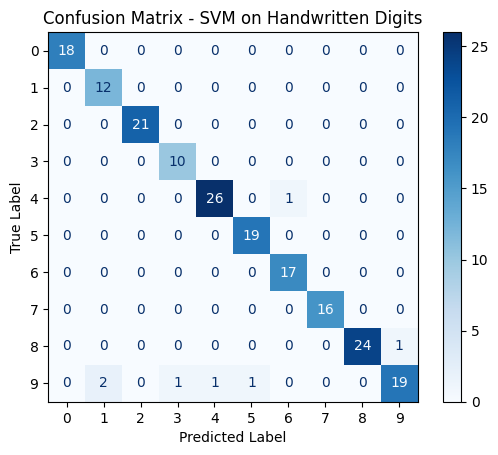

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Compute the confusion matrix
cm = confusion_matrix(ytest_svm, prediction)
print(cm)
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM on Handwritten Digits")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()